In [11]:
import sys
print("Python:", sys.executable)
import torch
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: /home/shobha/miniconda3/envs/glof38/bin/python3
PyTorch: 2.1.0a0+41361538.nv23.06
CUDA: True
GPU: Orin


In [12]:
import sys
print("Python:", sys.executable)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image, ImageEnhance
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              precision_recall_fscore_support,
                              accuracy_score)
import random, time, json, os, shutil, warnings
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available()
                      else "cpu")
print(f"✅ All libraries loaded")
print(f"✅ PyTorch: {torch.__version__}")
print(f"✅ Device:  {device}")
if device.type == "cuda":
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")

Python: /home/shobha/miniconda3/envs/glof38/bin/python3
✅ All libraries loaded
✅ PyTorch: 2.1.0a0+41361538.nv23.06
✅ Device:  cuda
✅ GPU: Orin


In [14]:
# ═══════════════════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════════════════

# ── Input PNG paths ────────────────────────────────────────────────

DATA_ROOT = "/home/shobha/Downloads/GLOF_Project"

CLASS_FOLDERS = {
    "Safe":      f"{DATA_ROOT}/Safe",
    "Dangerous": f"{DATA_ROOT}/Dangerous",
}

# ── Output paths ───────────────────────────────────────────────────
OUTPUT_DIR     = "/home/shobha/GLOF_Results_Binary"
AUG_DIR        = "/home/shobha/GLOF_Aug_Binary"
CHECKPOINT_DIR = "/home/shobha/GLOF_Checkpoints_Binary"

for d in [OUTPUT_DIR, AUG_DIR, CHECKPOINT_DIR]:
    os.makedirs(d, exist_ok=True)
for cls in ["Safe", "Dangerous"]:
    os.makedirs(f"{AUG_DIR}/{cls}", exist_ok=True)

# ── Classes ────────────────────────────────────────────────────────
CLASS_NAMES  = ["Safe", "Dangerous"]
CLASS_TO_IDX = {"Safe": 0, "Dangerous": 1}
IDX_TO_CLASS = {0: "Safe", 1: "Dangerous"}
NUM_CLASSES  = 2

# ── Image settings ─────────────────────────────────────────────────
IMAGE_SIZE    = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Data split ─────────────────────────────────────────────────────
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
RANDOM_SEED = 42

# ── Augmentation ───────────────────────────────────────────────────
# Dangerous gets more augmentation — fewer images
AUGMENT_TIMES = {
    "Safe":      4,
    "Dangerous": 8,
}

# ── Training — optimized for Jetson ───────────────────────────────
# Smaller batch size because Jetson has less VRAM
BATCH_SIZE          = 8    
NUM_WORKERS         = 2
PHASE1_EPOCHS       = 10
PHASE2_EPOCHS       = 15
PHASE1_LR           = 3e-3
PHASE2_LR           = 5e-5
LR_PATIENCE         = 5
LR_FACTOR           = 0.5
EARLY_STOP_PATIENCE = 7
UNFREEZE_LAYERS     = 10

# ── Reproducibility ────────────────────────────────────────────────
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

# ── Verify dataset folders ─────────────────────────────────────────

print(f"\n📁 Checking PNG dataset folders:")
total_png = 0
for cls, path in CLASS_FOLDERS.items():
    if os.path.exists(path):
        n = len([f for f in os.listdir(path)
                 if f.lower().endswith('.png')])
        total_png += n
        print(f"  ✅ {cls:<12}: {n} PNG files")
        print(f"     {path}")
    else:
        print(f"  ❌ {cls}: NOT FOUND at {path}")

print(f"\n  Total PNG: {total_png}")
print(f"  Device:    {device}")
print(f"\n  Training settings:")
print(f"  Batch size:  {BATCH_SIZE} "
      f"(small for Jetson VRAM)")
print(f"  Phase 1:     {PHASE1_EPOCHS} epochs "
      f"@ LR {PHASE1_LR}")
print(f"  Phase 2:     {PHASE2_EPOCHS} epochs "
      f"@ LR {PHASE2_LR}")
print(f"  Unfreeze:    {UNFREEZE_LAYERS} layers")
print(f"  Early stop:  {EARLY_STOP_PATIENCE}")


📁 Checking PNG dataset folders:
  ✅ Safe        : 369 PNG files
     /home/shobha/Downloads/GLOF_Project/Safe
  ✅ Dangerous   : 318 PNG files
     /home/shobha/Downloads/GLOF_Project/Dangerous

  Total PNG: 687
  Device:    cuda

  Training settings:
  Batch size:  8 (small for Jetson VRAM)
  Phase 1:     10 epochs @ LR 0.003
  Phase 2:     15 epochs @ LR 5e-05
  Unfreeze:    10 layers
  Early stop:  7


Step 1: Split originals first

  Safe        : 258 train | 55 val | 56 test (from 369 originals)
  Dangerous   : 222 train | 47 val | 49 test (from 318 originals)

 Step 2: Augment training only



  Safe:   0%|          | 0/258 [00:00<?, ?it/s]

  ✅ Safe        : 258 original + 1032 augmented = 1290 train total



  Dangerous:   0%|          | 0/222 [00:00<?, ?it/s]

  ✅ Dangerous   : 222 original + 1776 augmented = 1998 train total

  DATASET SUMMARY

  Split     Total    Safe   Dangerous
  ─────────────────────────────────────
  Train      3288    1290        1998
  Val         102      55          47
  Test        105      56          49

  Class weights:
    Safe:      1.5488
    Dangerous: 1.0000


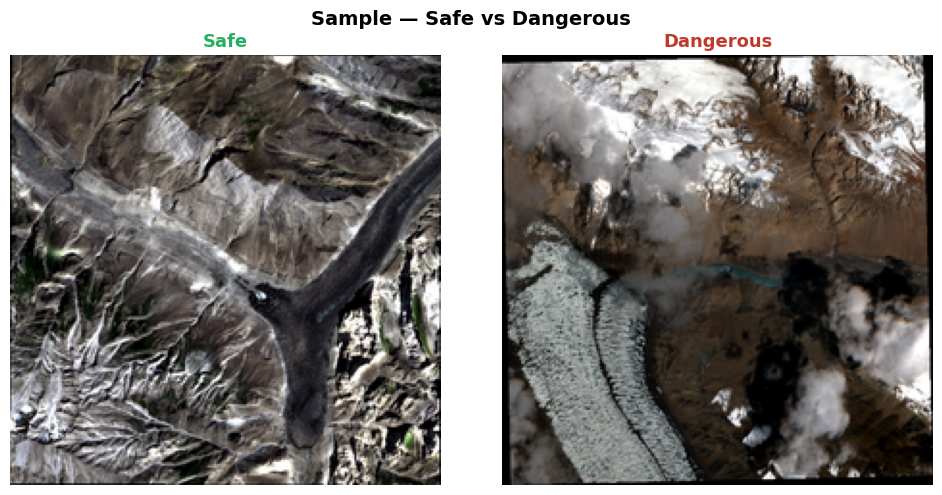

✅ Sample images saved!


In [15]:
# ═══════════════════════════════════════════════════════════════════
# STEP 1: Split originals FIRST → augment training ONLY
# assuring data leakage between splits
# ═══════════════════════════════════════════════════════════════════

def augment_image(img: Image.Image,
                  strategy: int) -> Image.Image:
    """8 augmentation strategies."""
    aug = img.copy()
    s   = strategy % 8
    if   s == 0: aug = aug.rotate(90)
    elif s == 1: aug = aug.rotate(180)
    elif s == 2: aug = aug.rotate(270)
    elif s == 3: aug = aug.transpose(
        Image.FLIP_LEFT_RIGHT)
    elif s == 4: aug = aug.transpose(
        Image.FLIP_TOP_BOTTOM)
    elif s == 5:
        aug = ImageEnhance.Brightness(
            aug).enhance(
            random.uniform(0.7, 1.3))
    elif s == 6:
        aug = ImageEnhance.Contrast(
            aug).enhance(
            random.uniform(0.8, 1.4))
    elif s == 7:
        w, h = aug.size
        m    = int(w * 0.1)
        l    = random.randint(0, m)
        t    = random.randint(0, m)
        r_   = w - random.randint(0, m)
        b_   = h - random.randint(0, m)
        aug  = aug.crop((l, t, r_, b_))
        aug  = aug.resize(
            (IMAGE_SIZE, IMAGE_SIZE),
            Image.LANCZOS)
    return aug



print("Step 1: Split originals first\n")

train_orig, val_orig, test_orig = [], [], []

for cls in CLASS_NAMES:
    label  = CLASS_TO_IDX[cls]
    folder = Path(CLASS_FOLDERS[cls])
    files  = list(folder.glob("*.png"))

    if not files:
        print(f"  {cls}: No PNG files found!")
        continue

    random.shuffle(files)
    n = len(files)
    t = int(n * TRAIN_RATIO)
    v = int(n * VAL_RATIO)

    for f in files[:t]:
        train_orig.append({
            "filepath":   str(f),
            "label":      label,
            "class_name": cls})
    for f in files[t:t+v]:
        val_orig.append({
            "filepath":   str(f),
            "label":      label,
            "class_name": cls})
    for f in files[t+v:]:
        test_orig.append({
            "filepath":   str(f),
            "label":      label,
            "class_name": cls})

    print(f"  {cls:<12}: "
          f"{len(files[:t])} train | "
          f"{len(files[t:t+v])} val | "
          f"{len(files[t+v:])} test "
          f"(from {n} originals)")

print(f"\n Step 2: Augment training only\n")
all_train = list(train_orig)

for cls in CLASS_NAMES:
    label   = CLASS_TO_IDX[cls]
    aug_dir = Path(AUG_DIR) / cls
    aug_dir.mkdir(parents=True, exist_ok=True)

    cls_train = [
        Path(r["filepath"])
        for r in train_orig
        if r["class_name"] == cls
    ]

    times       = AUGMENT_TIMES[cls]
    aug_created = 0

    for img_path in tqdm(cls_train,
                         desc=f"  {cls}",
                         colour='cyan'):
        try:
            img = Image.open(
                img_path).convert("RGB")
            for i in range(times):
                aug_name = (f"{img_path.stem}"
                            f"_aug{i}.png")
                aug_path = aug_dir / aug_name
                if not aug_path.exists():
                    augment_image(
                        img, i).save(aug_path)
                all_train.append({
                    "filepath":   str(aug_path),
                    "label":      label,
                    "class_name": cls,
                })
                aug_created += 1
        except Exception as e:
            print(f"Error: {e}")

    print(f"  ✅ {cls:<12}: "
          f"{len(cls_train)} original "
          f"+ {aug_created} augmented "
          f"= {len(cls_train)+aug_created}"
          f" train total\n")

random.shuffle(all_train)

# Save manifests
train_df = pd.DataFrame(all_train)
val_df   = pd.DataFrame(val_orig)
test_df  = pd.DataFrame(test_orig)

train_df.to_csv(
    f"{OUTPUT_DIR}/train_manifest.csv",
    index=False)
val_df.to_csv(
    f"{OUTPUT_DIR}/val_manifest.csv",
    index=False)
test_df.to_csv(
    f"{OUTPUT_DIR}/test_manifest.csv",
    index=False)

# Class weights for imbalanced data
safe_n = len([r for r in all_train
              if r["class_name"] == "Safe"])
dang_n = len([r for r in all_train
              if r["class_name"] == "Dangerous"])
max_n  = max(safe_n, dang_n)

CLASS_WEIGHTS = {
    0: max_n / safe_n,
    1: max_n / dang_n,
}

print(f"{'='*50}")
print(f"  DATASET SUMMARY")
print(f"{'='*50}")
print(f"\n  {'Split':<8}{'Total':>7}"
      f"{'Safe':>8}{'Dangerous':>12}")
print(f"  {'─'*37}")
for name, df in [("Train", train_df),
                 ("Val",   val_df),
                 ("Test",  test_df)]:
    s = len(df[df['class_name'] == 'Safe'])
    d = len(df[df['class_name'] == 'Dangerous'])
    print(f"  {name:<8}{len(df):>7}"
          f"{s:>8}{d:>12}")

print(f"\n  Class weights:")
print(f"    Safe:      {CLASS_WEIGHTS[0]:.4f}")
print(f"    Dangerous: {CLASS_WEIGHTS[1]:.4f}")
print(f"{'='*50}")

# Show sample images
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Sample — Safe vs Dangerous",
             fontsize=14, fontweight='bold')
for ax, cls in zip(axes, CLASS_NAMES):
    folder = Path(CLASS_FOLDERS[cls])
    files  = list(folder.glob("*.png"))
    if files:
        img   = Image.open(
            random.choice(files))
        color = ('#27ae60' if cls == 'Safe'
                 else '#c0392b')
        ax.imshow(img)
        ax.set_title(cls,
                     fontweight='bold',
                     color=color,
                     fontsize=13)
        ax.axis('off')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/sample_images.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sample images saved!")

In [6]:
# ═══════════════════════════════════════════════════════════════════
# STEP 2: Train EfficientNet-B0
# Phase 1: Frozen backbone — train head only
# Phase 2: Unfreeze last 10 layers — fine-tune
# ═══════════════════════════════════════════════════════════════════

class GLOFDataset(Dataset):
    def __init__(self, manifest_path: str,
                 transform=None):
        self.df        = pd.read_csv(manifest_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(
                row["filepath"]).convert("RGB")
        except Exception:
            img = Image.new(
                "RGB",
                (IMAGE_SIZE, IMAGE_SIZE),
                (0, 0, 0))
        if self.transform:
            img = self.transform(img)
        return img, int(row["label"])


train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD),
])

train_loader = DataLoader(
    GLOFDataset(
        f"{OUTPUT_DIR}/train_manifest.csv",
        train_transform),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True)

val_loader = DataLoader(
    GLOFDataset(
        f"{OUTPUT_DIR}/val_manifest.csv",
        eval_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True)

print(f"  Train: {len(train_loader.dataset):,}")
print(f"  Val:   {len(val_loader.dataset):,}")

# ── Build EfficientNet-B0 ──────────────────────────────────────────
model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights
                   .IMAGENET1K_V1)
in_f = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.5, inplace=True),
    nn.Linear(in_f, 512),   
    nn.ReLU(),
    nn.BatchNorm1d(512),   
    nn.Dropout(p=0.3),
    nn.Linear(512, 128),    
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(128, NUM_CLASSES),
)
model = model.to(device)

total_params = sum(
    p.numel() for p in model.parameters())
print(f"\n✅ EfficientNet-B0 loaded")
print(f"   Parameters: {total_params:,}")
print(f"   Dropout:    0.5 → 0.4")

weights_t = torch.tensor(
    [CLASS_WEIGHTS[i]
     for i in range(NUM_CLASSES)],
    dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(
    weight=weights_t)


def train_epoch(model, loader, optimizer):
    model.train()
    loss_sum = correct = total = 0
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * len(imgs)
        correct  += (out.argmax(1) == labels
                     ).sum().item()
        total    += len(imgs)
    return loss_sum / total, correct / total


def eval_epoch(model, loader):
    model.eval()
    loss_sum = correct = total = 0
    all_preds  = []
    all_labels = []
    all_probs  = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            labels = labels.to(device)
            out    = model(imgs)
            loss   = criterion(out, labels)
            probs  = torch.softmax(out, dim=1)
            loss_sum += loss.item() * len(imgs)
            preds = out.argmax(1)
            correct  += (preds == labels
                         ).sum().item()
            total    += len(imgs)
            all_preds.extend(
                preds.cpu().numpy())
            all_labels.extend(
                labels.cpu().numpy())
            all_probs.extend(
                probs[:, 1].cpu().numpy())
    return (loss_sum / total,
            correct / total,
            all_preds,
            all_labels,
            all_probs)


def run_phase(phase, epochs, lr,
              freeze=True):
    print(f"\n{'='*55}")
    print(f"  PHASE {phase} — "
          f"{'Transfer Learning' if phase==1 else 'Fine-Tuning'}")
    print(f"  Epochs:{epochs}  LR:{lr}")
    print(f"{'='*55}")

    for p in model.features.parameters():
        p.requires_grad = False

    if not freeze:
        layers = list(
            model.features.children())
        for layer in layers[-UNFREEZE_LAYERS:]:
            for p in layer.parameters():
                p.requires_grad = True
        print(f"  Unfroze last "
              f"{UNFREEZE_LAYERS} layers")

    trainable = sum(
        p.numel() for p in model.parameters()
        if p.requires_grad)
    print(f"  Trainable: {trainable:,}\n")

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad,
               model.parameters()),
        lr=lr,
        weight_decay=1e-4)

    scheduler = optim.lr_scheduler\
        .ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=LR_FACTOR,
            patience=LR_PATIENCE)

    best_loss    = float('inf')
    patience_ctr = 0
    history = {k: [] for k in
               ["train_loss", "train_acc",
                "val_loss",   "val_acc"]}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_l, tr_a = train_epoch(
            model, train_loader, optimizer)
        vl_l, vl_a, _, _, _ = eval_epoch(
            model, val_loader)
        scheduler.step(vl_l)

        history["train_loss"].append(tr_l)
        history["train_acc"].append(tr_a)
        history["val_loss"].append(vl_l)
        history["val_acc"].append(vl_a)

        lr_now = optimizer.param_groups[0]['lr']
        gap    = abs(tr_a - vl_a)
        flag   = (" ⚠️ overfit!"
                  if gap > 0.15 else "")

        print(f"  Ep {epoch:>2}/{epochs} | "
              f"Tr:{tr_l:.4f}/{tr_a:.3f} | "
              f"Val:{vl_l:.4f}/{vl_a:.3f} | "
              f"Gap:{gap:.3f}{flag} | "
              f"LR:{lr_now:.0e} | "
              f"{time.time()-t0:.0f}s")

        if vl_l < best_loss:
            best_loss    = vl_l
            patience_ctr = 0
            torch.save(
                model.state_dict(),
                f"{CHECKPOINT_DIR}/"
                f"best_p{phase}.pth")
            print(f"    💾 Saved! "
                  f"(val={vl_l:.4f})")
        else:
            patience_ctr += 1
            print(f"    No improvement "
                  f"({patience_ctr}/"
                  f"{EARLY_STOP_PATIENCE})")
            if patience_ctr >= EARLY_STOP_PATIENCE:
                print(f"\n  ⏹ Early stopping "
                      f"at epoch {epoch}")
                break

    model.load_state_dict(torch.load(
        f"{CHECKPOINT_DIR}/best_p{phase}.pth",
        map_location=device))
    print(f"\n  ✅ Phase {phase} done! "
          f"Best: {best_loss:.4f}")
    return history


# ── Run both phases ────────────────────────────────────────────────
history1 = run_phase(
    1, PHASE1_EPOCHS, PHASE1_LR, True)
history2 = run_phase(
    2, PHASE2_EPOCHS, PHASE2_LR, False)

# ── Save model and history ─────────────────────────────────────────
torch.save(model.state_dict(),
           f"{OUTPUT_DIR}/final_model.pth")
full_history = {"phase1": history1,
                "phase2": history2}
with open(
        f"{OUTPUT_DIR}/training_history.json",
        "w") as f:
    json.dump(full_history, f, indent=2)

print(f"\n✅ Training complete!")
print(f"   Model: {OUTPUT_DIR}/final_model.pth")

  Train: 3,288
  Val:   102

✅ EfficientNet-B0 loaded
   Parameters: 4,730,366
   Dropout:    0.5 → 0.4

  PHASE 1 — Transfer Learning
  Epochs:10  LR:0.003
  Trainable: 722,818

  Ep  1/10 | Tr:0.5690/0.734 | Val:0.5873/0.706 | Gap:0.028 | LR:3e-03 | 33s
    💾 Saved! (val=0.5873)
  Ep  2/10 | Tr:0.5151/0.762 | Val:0.5600/0.725 | Gap:0.037 | LR:3e-03 | 27s
    💾 Saved! (val=0.5600)
  Ep  3/10 | Tr:0.5025/0.775 | Val:0.5476/0.775 | Gap:0.000 | LR:3e-03 | 27s
    💾 Saved! (val=0.5476)
  Ep  4/10 | Tr:0.4845/0.792 | Val:0.5291/0.755 | Gap:0.037 | LR:3e-03 | 27s
    💾 Saved! (val=0.5291)
  Ep  5/10 | Tr:0.4802/0.790 | Val:0.5013/0.765 | Gap:0.025 | LR:3e-03 | 27s
    💾 Saved! (val=0.5013)
  Ep  6/10 | Tr:0.4397/0.819 | Val:0.7868/0.735 | Gap:0.084 | LR:3e-03 | 27s
    No improvement (1/7)
  Ep  7/10 | Tr:0.4523/0.807 | Val:0.5293/0.706 | Gap:0.101 | LR:3e-03 | 27s
    No improvement (2/7)
  Ep  8/10 | Tr:0.4352/0.808 | Val:0.5363/0.765 | Gap:0.043 | LR:3e-03 | 27s
    No improvement (3/7)


  Test set: 105 images



  Predicting:   0%|          | 0/14 [00:00<?, ?it/s]


  FINAL RESULTS — Default Threshold (0.50)
  Precision and Recall calculated here

  Overall Accuracy: 84.76%
  AUC-ROC:          0.9173
  Avg Precision:    0.8902

  Class             Prec     Rec      F1       N
  ──────────────────────────────────────────────
  Safe            0.8704  0.8393  0.8545      56
  Dangerous       0.8235  0.8571  0.8400      49 ⬅ KEY

  Dangerous Recall: 85.7%  ✅ EXCELLENT

  THREE-TIER DISPLAY SYSTEM

  🟢 TIER 1 — SAFE
     prob < 0.35 → shown as Safe to user
     Count: 49 lakes
     Correctly Safe:   43
     Dangerous missed: 6 ⚠️

  🟡 TIER 2 — EXPERT REVIEW NEEDED
     prob 0.35 to 0.6 → shown as Uncertain to user
     Count: 12 lakes
     Safe lakes here:      7
     Dangerous lakes here: 5
     → Human expert reviews all 12

  🔴 TIER 3 — DANGEROUS ALERT
     prob > 0.6 → shown as Dangerous to user
     Count: 44 lakes
     Correctly Dangerous: 38
     False alarms:        6

  SYSTEM COVERAGE:
  Total Dangerous:    49
  Caught (T2 + T3):  43 (87.8%

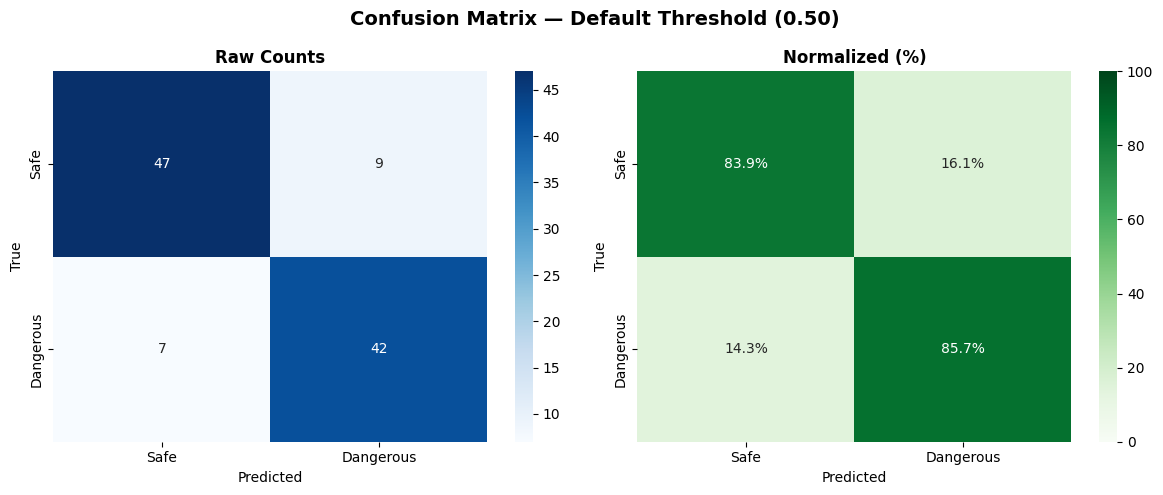

✅ Confusion matrix saved!


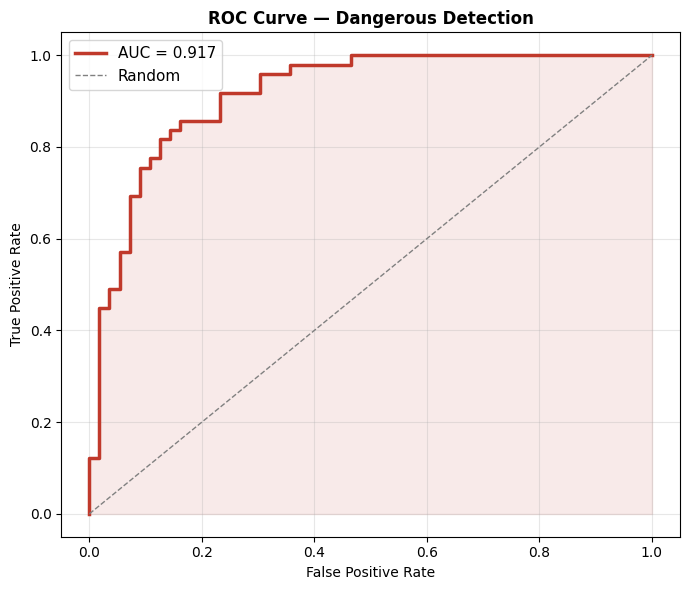

✅ ROC curve saved!


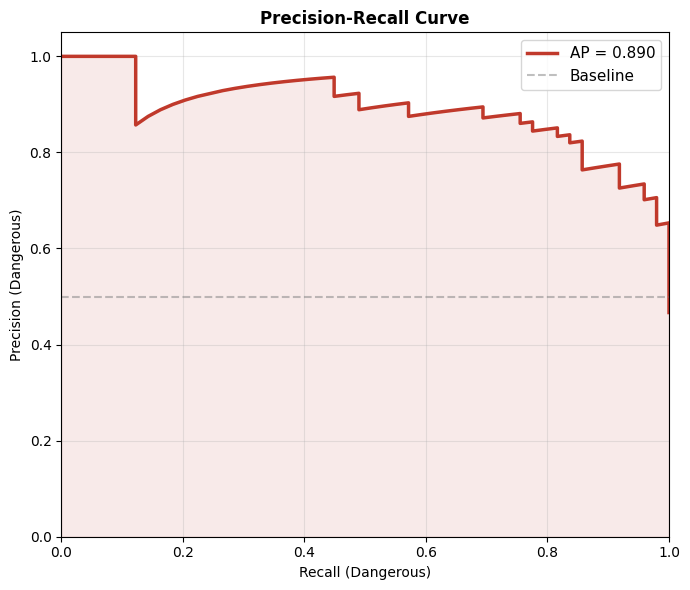

✅ Precision-Recall curve saved!


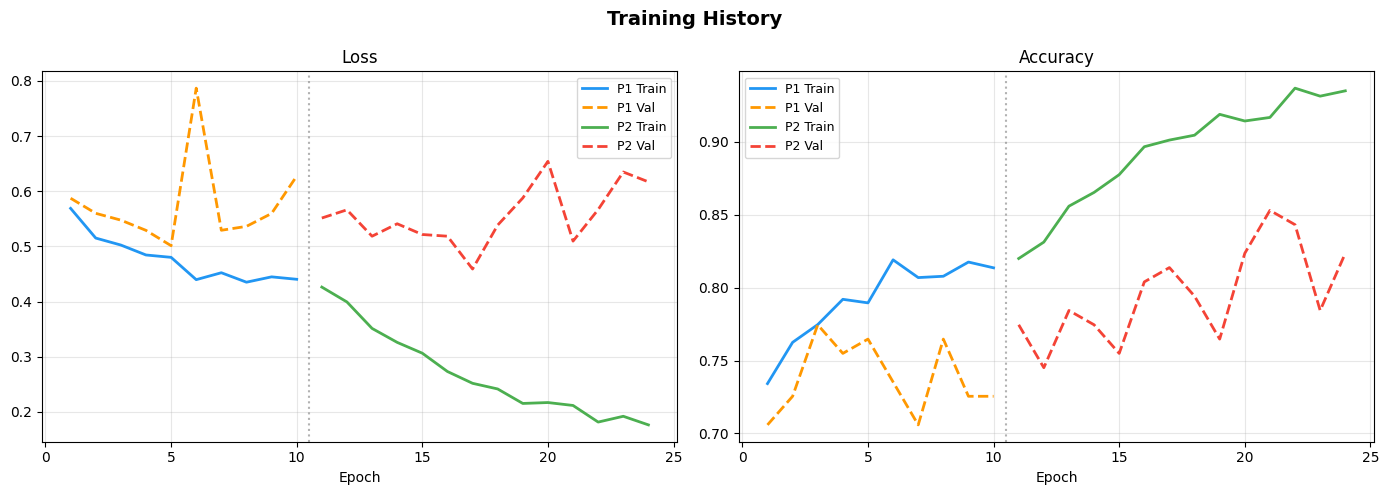

✅ Training curves saved!


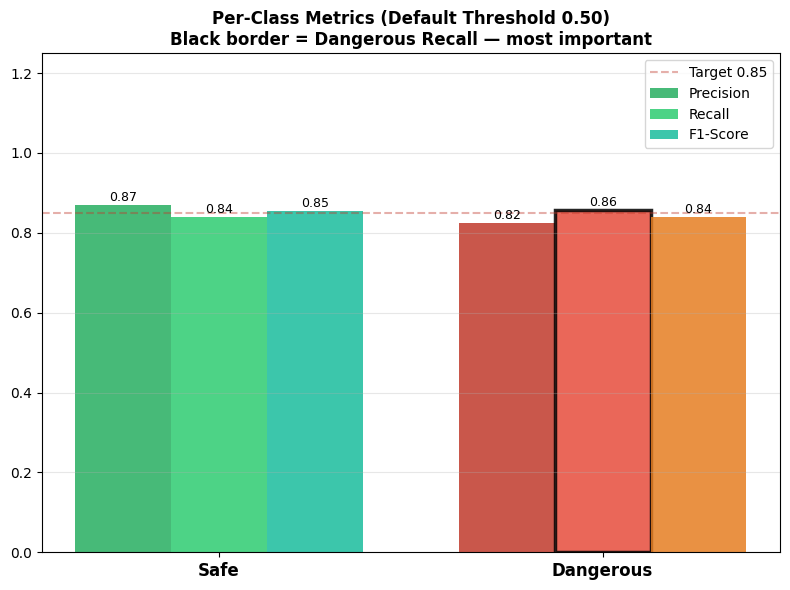

✅ Per-class metrics saved!


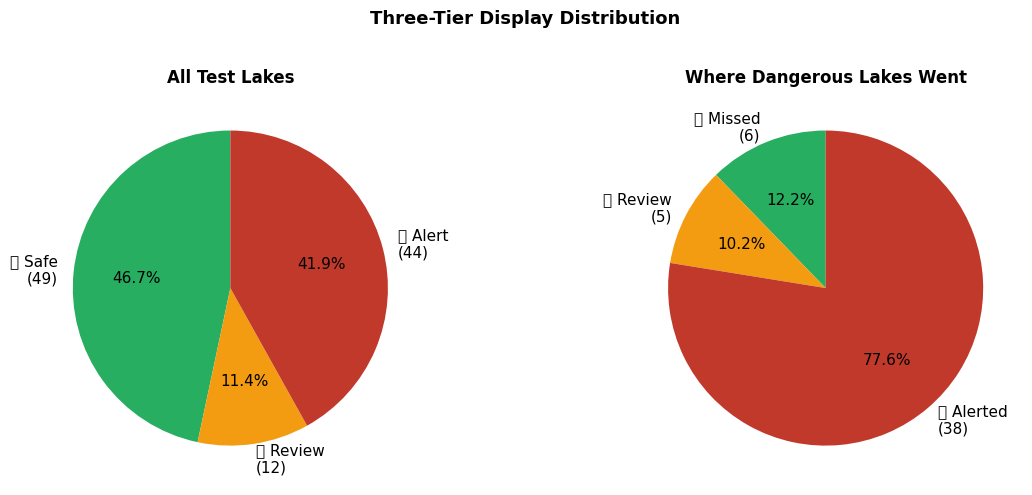

✅ Tier distribution saved!

  FINAL SUMMARY

  Model Performance (threshold 0.50):
    Accuracy:         84.76%
    AUC-ROC:          0.9173
    Dangerous Recall: 85.7%
    Safe Recall:      83.9%

  Three-Tier Display (for users):
    🟢 Safe:          49 lakes
    🟡 Expert Review: 12 lakes
    🔴 Alert:         44 lakes

  Dangerous Lakes Coverage:
    Total:    49
    Caught:   43 (87.8%)
    Missed:   6 (12.2%)

  Saved:
  ├── confusion_matrix.png
  ├── roc_curve.png
  ├── precision_recall_curve.png
  ├── training_curves.png
  ├── per_class_metrics.png
  ├── tier_distribution.png
  ├── classification_report.csv
  └── predictions.csv

🎉 Evaluation complete!


In [17]:
# ═══════════════════════════════════════════════════════════════════
# STEP 4: Professional Evaluation
# Default threshold: 0.50
# Three-tier display: Safe / Expert Review / Dangerous
# Thresholds: <35% Safe | 35-60% Review | >60% Dangerous
# ═══════════════════════════════════════════════════════════════════

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    recall_score,
    precision_score,
    average_precision_score,
    precision_recall_curve
)

# ── Three-tier display thresholds ─────────────────────────────────
# These are ONLY for displaying results to user
# They do NOT affect recall or precision
# Model still predicts using default 0.50
SAFE_THRESHOLD   = 0.35
DANGER_THRESHOLD = 0.60

# ── Get all predictions ───────────────────────────────────────────
test_loader = DataLoader(
    GLOFDataset(
        f"{OUTPUT_DIR}/test_manifest.csv",
        eval_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS)

print(f"  Test set: {len(test_loader.dataset)} images\n")

model.eval()
y_true, y_pred, y_probs = [], [], []

with torch.no_grad():
    for imgs, labels in tqdm(
            test_loader,
            desc="  Predicting",
            colour='blue'):
        imgs  = imgs.to(device)
        out   = model(imgs)
        probs = torch.softmax(out, dim=1)
        preds = out.argmax(1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())
        y_probs.extend(
            probs[:, 1].cpu().numpy())

y_true  = np.array(y_true)
y_pred  = np.array(y_pred)
y_probs = np.array(y_probs)

# ── Results at default threshold (0.50) ───────────────────────────
# This is the REAL precision and recall
acc = accuracy_score(y_true, y_pred)
precision, recall, f1, support = \
    precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1])
auc = roc_auc_score(y_true, y_probs)
ap  = average_precision_score(
    y_true, y_probs)

dang_idx    = CLASS_NAMES.index("Dangerous")
dang_recall = recall[dang_idx]

print(f"\n{'='*55}")
print(f"  FINAL RESULTS — Default Threshold (0.50)")
print(f"  Precision and Recall calculated here")
print(f"{'='*55}")
print(f"\n  Overall Accuracy: {acc*100:.2f}%")
print(f"  AUC-ROC:          {auc:.4f}")
print(f"  Avg Precision:    {ap:.4f}\n")
print(f"  {'Class':<14}{'Prec':>8}"
      f"{'Rec':>8}{'F1':>8}{'N':>8}")
print(f"  {'─'*46}")
for i, cls in enumerate(CLASS_NAMES):
    mk = " ⬅ KEY" if cls == "Dangerous" else ""
    print(f"  {cls:<14}"
          f"{precision[i]:>8.4f}"
          f"{recall[i]:>8.4f}"
          f"{f1[i]:>8.4f}"
          f"{support[i]:>8}{mk}")

status = ("✅ EXCELLENT" if dang_recall >= 0.85
          else "✅ GOOD"  if dang_recall >= 0.70
          else "⚠️  FAIR" if dang_recall >= 0.60
          else "❌ NEEDS WORK")
print(f"\n  Dangerous Recall: "
      f"{dang_recall*100:.1f}%  {status}")

# ── Three-tier display system ─────────────────────────────────────
# This is ONLY for displaying results
# Does NOT change precision or recall
print(f"\n{'='*55}")
print(f"  THREE-TIER DISPLAY SYSTEM")
print(f"{'='*55}")

tier1_mask = y_probs <  SAFE_THRESHOLD
tier2_mask = ((y_probs >= SAFE_THRESHOLD) &
              (y_probs <  DANGER_THRESHOLD))
tier3_mask = y_probs >= DANGER_THRESHOLD

t1_total  = tier1_mask.sum()
t1_missed = (y_true[tier1_mask] == 1).sum()
t1_correct= (y_true[tier1_mask] == 0).sum()

t2_total  = tier2_mask.sum()
t2_dang   = (y_true[tier2_mask] == 1).sum()
t2_safe   = (y_true[tier2_mask] == 0).sum()

t3_total  = tier3_mask.sum()
t3_correct= (y_true[tier3_mask] == 1).sum()
t3_false  = (y_true[tier3_mask] == 0).sum()

print(f"\n  🟢 TIER 1 — SAFE")
print(f"     prob < {SAFE_THRESHOLD} "
      f"→ shown as Safe to user")
print(f"     Count: {t1_total} lakes")
print(f"     Correctly Safe:   {t1_correct}")
print(f"     Dangerous missed: {t1_missed} "
      f"{'⚠️' if t1_missed > 0 else '✅ None!'}")

print(f"\n  🟡 TIER 2 — EXPERT REVIEW NEEDED")
print(f"     prob {SAFE_THRESHOLD} to "
      f"{DANGER_THRESHOLD} "
      f"→ shown as Uncertain to user")
print(f"     Count: {t2_total} lakes")
print(f"     Safe lakes here:      {t2_safe}")
print(f"     Dangerous lakes here: {t2_dang}")
print(f"     → Human expert reviews all {t2_total}")

print(f"\n  🔴 TIER 3 — DANGEROUS ALERT")
print(f"     prob > {DANGER_THRESHOLD} "
      f"→ shown as Dangerous to user")
print(f"     Count: {t3_total} lakes")
print(f"     Correctly Dangerous: {t3_correct}")
print(f"     False alarms:        {t3_false}")

total_dang  = (y_true == 1).sum()
caught      = ((y_true == 1) &
               (y_probs >= SAFE_THRESHOLD)).sum()
missed      = t1_missed

print(f"\n  SYSTEM COVERAGE:")
print(f"  Total Dangerous:    {total_dang}")
print(f"  Caught (T2 + T3):  {caught} "
      f"({caught/total_dang*100:.1f}%)")
print(f"  Missed (T1):       {missed} "
      f"({missed/total_dang*100:.1f}%)")

# ── Plot 1: Confusion Matrix ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    "Confusion Matrix — Default Threshold (0.50)",
    fontsize=14, fontweight='bold')

cm      = confusion_matrix(y_true, y_pred)
cm_norm = (cm.astype(float) /
           cm.sum(axis=1, keepdims=True) * 100)

sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            ax=axes[0])
axes[0].set_title("Raw Counts",
                  fontweight='bold')
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

annot = np.array(
    [[f"{v:.1f}%" for v in row]
     for row in cm_norm])
sns.heatmap(cm_norm, annot=annot, fmt='',
            cmap='Greens',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            ax=axes[1], vmin=0, vmax=100)
axes[1].set_title("Normalized (%)",
                  fontweight='bold')
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/confusion_matrix.png",
    dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved!")

# ── Plot 2: ROC Curve ─────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_true, y_probs)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#c0392b',
        linewidth=2.5,
        label=f'AUC = {auc:.3f}')
ax.plot([0,1],[0,1], color='grey',
        linestyle='--', linewidth=1,
        label='Random')
ax.fill_between(fpr, tpr,
                alpha=0.1, color='#c0392b')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(
    "ROC Curve — Dangerous Detection",
    fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curve.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC curve saved!")

# ── Plot 3: Precision-Recall Curve ────────────────────────────────
prec_curve, rec_curve, _ = \
    precision_recall_curve(y_true, y_probs)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(rec_curve, prec_curve,
        color='#c0392b', linewidth=2.5,
        label=f'AP = {ap:.3f}')
ax.fill_between(rec_curve, prec_curve,
                alpha=0.1, color='#c0392b')
ax.axhline(y=0.5, color='grey',
           linestyle='--', alpha=0.5,
           label='Baseline')
ax.set_xlabel("Recall (Dangerous)")
ax.set_ylabel("Precision (Dangerous)")
ax.set_title(
    "Precision-Recall Curve",
    fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/precision_recall_curve.png",
    dpi=150, bbox_inches='tight')
plt.show()
print("✅ Precision-Recall curve saved!")

# ── Plot 4: Training Curves ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training History",
             fontsize=14, fontweight='bold')
COLORS = [('#2196F3','#FF9800'),
          ('#4CAF50','#F44336')]
offset = 0
for i, phase in enumerate(
        ['phase1','phase2']):
    h      = full_history[phase]
    x      = range(
        offset+1,
        offset+len(h['train_loss'])+1)
    ct, cv = COLORS[i]
    for ax, m in zip(axes, ['loss','acc']):
        ax.plot(x, h[f'train_{m}'],
                color=ct,
                label=f'P{i+1} Train',
                linewidth=2)
        ax.plot(x, h[f'val_{m}'],
                color=cv,
                label=f'P{i+1} Val',
                linewidth=2,
                linestyle='--')
        if offset > 0:
            ax.axvline(x=offset+0.5,
                       color='grey',
                       linestyle=':',
                       alpha=0.6)
    offset += len(h['train_loss'])
axes[0].set_title("Loss")
axes[1].set_title("Accuracy")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/training_curves.png",
    dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved!")

# ── Plot 5: Per-Class Metrics ─────────────────────────────────────
x, w = np.arange(NUM_CLASSES), 0.25
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x-w, precision, w,
       label='Precision',
       color=['#27ae60','#c0392b'],
       alpha=0.85)
br = ax.bar(x, recall, w,
            label='Recall',
            color=['#2ecc71','#e74c3c'],
            alpha=0.85)
ax.bar(x+w, f1, w,
       label='F1-Score',
       color=['#1abc9c','#e67e22'],
       alpha=0.85)
br[dang_idx].set_edgecolor('black')
br[dang_idx].set_linewidth(2.5)
for bars in [ax.containers[0],
             ax.containers[1],
             ax.containers[2]]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x()+bar.get_width()/2,
            h+0.01, f'{h:.2f}',
            ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES,
                   fontweight='bold',
                   fontsize=12)
ax.set_ylim(0, 1.25)
ax.axhline(y=0.85, color='#c0392b',
           linestyle='--', alpha=0.4,
           label='Target 0.85')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_title(
    "Per-Class Metrics (Default Threshold 0.50)\n"
    "Black border = Dangerous Recall — most important",
    fontweight='bold')
plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/per_class_metrics.png",
    dpi=150, bbox_inches='tight')
plt.show()
print("✅ Per-class metrics saved!")

# ── Plot 6: Three-tier pie chart ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    "Three-Tier Display Distribution\n",
    fontsize=13, fontweight='bold')

colors = ['#27ae60','#f39c12','#c0392b']

# All lakes
sizes = [t1_total, t2_total, t3_total]
labels = [
    f'🟢 Safe\n({t1_total})',
    f'🟡 Review\n({t2_total})',
    f'🔴 Alert\n({t3_total})']
axes[0].pie(sizes, labels=labels,
            colors=colors,
            autopct='%1.1f%%',
            startangle=90,
            textprops={'fontsize': 11})
axes[0].set_title("All Test Lakes",
                  fontweight='bold')

# Dangerous lakes only
dang_t1 = (y_true[tier1_mask] == 1).sum()
dang_t2 = (y_true[tier2_mask] == 1).sum()
dang_t3 = (y_true[tier3_mask] == 1).sum()

sizes_d  = [dang_t1, dang_t2, dang_t3]
labels_d = [
    f'🟢 Missed\n({dang_t1})',
    f'🟡 Review\n({dang_t2})',
    f'🔴 Alerted\n({dang_t3})']

if sum(sizes_d) > 0:
    axes[1].pie(sizes_d, labels=labels_d,
                colors=colors,
                autopct='%1.1f%%',
                startangle=90,
                textprops={'fontsize': 11})
axes[1].set_title(
    "Where Dangerous Lakes Went",
    fontweight='bold')

plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/tier_distribution.png",
    dpi=150, bbox_inches='tight')
plt.show()
print("✅ Tier distribution saved!")

# ── Save reports ──────────────────────────────────────────────────
pd.DataFrame(
    classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        output_dict=True)
).transpose().to_csv(
    f"{OUTPUT_DIR}/classification_report.csv")

pd.DataFrame({
    "true":       [CLASS_NAMES[i]
                   for i in y_true],
    "predicted":  [CLASS_NAMES[i]
                   for i in y_pred],
    "correct":     y_true == y_pred,
    "prob_safe":   1 - y_probs,
    "prob_danger": y_probs,
    "confidence":  np.where(
        y_pred == 1,
        y_probs, 1 - y_probs),
    "display_tier": np.where(
        y_probs < SAFE_THRESHOLD,
        "Safe",
        np.where(
            y_probs < DANGER_THRESHOLD,
            "Expert Review",
            "Alert")),
}).to_csv(
    f"{OUTPUT_DIR}/predictions.csv",
    index=False)

# ── Final summary ─────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  FINAL SUMMARY")
print(f"{'='*55}")
print(f"\n  Model Performance (threshold 0.50):")
print(f"    Accuracy:         {acc*100:.2f}%")
print(f"    AUC-ROC:          {auc:.4f}")
print(f"    Dangerous Recall: {dang_recall*100:.1f}%")
print(f"    Safe Recall:      {recall[0]*100:.1f}%")
print(f"\n  Three-Tier Display (for users):")
print(f"    🟢 Safe:          {t1_total} lakes")
print(f"    🟡 Expert Review: {t2_total} lakes")
print(f"    🔴 Alert:         {t3_total} lakes")
print(f"\n  Dangerous Lakes Coverage:")
print(f"    Total:    {total_dang}")
print(f"    Caught:   {caught} "
      f"({caught/total_dang*100:.1f}%)")
print(f"    Missed:   {missed} "
      f"({missed/total_dang*100:.1f}%)")
print(f"\n  Saved:")
print(f"  ├── confusion_matrix.png")
print(f"  ├── roc_curve.png")
print(f"  ├── precision_recall_curve.png")
print(f"  ├── training_curves.png")
print(f"  ├── per_class_metrics.png")
print(f"  ├── tier_distribution.png")
print(f"  ├── classification_report.csv")
print(f"  └── predictions.csv")
print(f"\n🎉 Evaluation complete!")